# Phase II: Data Curation, Exploratory Analysis and Plotting 

### Team Members: Kaung Mo, Ian Menachery, Komal Jain, Sunithi Krishnan

Like most college students, we love watching many different types of movies. These movies have many different attributes like genres, and awards won. As a result, they also have varying critic scores and revenue generated. So, for our project, we wanted to study two central questions:  Can we use (input data) to predict a movie's IMDB score and Can we use (input data) to predict a movie's box office revenue? 

For our data collection, we start by using api keys, concatenating a string url to request from. 
First we get a list of 1000 movie titles using Tmdb, a database that contains general information about movies. Then, we use requests.get to obtain the 1000 titles of all movies whose release date is before 2024-10-24, are in english, have received wide theatrical release and sorted by popularity descending order. The function checks for errors and returns error messages. Now we collected omdb details for all 1000 movies because omdb has a more complete set of information. Then we have a function that loops through every movie in the list of 1000 movie titles, and collects omdb data for each. Some minor cleaning is done like separating the rating sources into rotten tomatoes and internet movie databas and then the data for each movie is added to the dataframe. Finally we clean the dataframe by making all the numerical columns actually of numeric type.


In [3]:
import requests
import pandas as pd

#necessary api keys
tmdb_api_key = 'dddd9b6ff9994832169b9eeb1a14db90'
omdb_api_key = 'd56f5f97'


#function to get list of movies
def get_movies(movie_count):
    movies = []
    page = 1

    #while loop used in case we need to test different counts of movies
    while len(movies) < movie_count:
        url = (f"https://api.themoviedb.org/3/discover/movie?api_key={tmdb_api_key}&sort_by=popularity.desc&primary_release_date.lte=2024-10-24&with_original_language=en&with_release_type=3&page={page}")
        response = requests.get(url)
        #gives info if request fails
        if response.status_code != 200:
            print('Error: ' + response.status_code)
        data = response.json()
        results = data.get('results', [])
        movies.extend(results)

        page += 1

    return movies

#populate 1000 movies
movies = get_movies(1000)


#request from omdb using the list of movies we got above, searching by title
def get_omdb_details(title):
    url = f"http://www.omdbapi.com/?apikey={omdb_api_key}&t={title}"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    else:
        print('Error: ' + response.status_code)
        return None

#function that takes in a list of movie titles and gives us a uncleaned df
def build_movies_dataframe(movies):
    detailed_movies = []

    #gets the omdb data
    for movie in movies:
        title = movie.get('title')
        movie_data = get_omdb_details(title)
        ratings = movie_data.get('Ratings', [])
        # Initialize default values
        rotten_tomato_rating = 'N/A'  # or None, or any other default
        imd_rating = 'N/A'  # or None, or any other default
        #splits the 2 rating sources
        for rating in ratings:
            if rating['Source'] == 'Rotten Tomatoes':
                rotten_tomato_rating = rating['Value']
            if rating['Source'] == 'Internet Movie Database':
                imd_rating = rating['Value']
        #append all details into df
        detailed_movies.append({
            'Title': movie_data.get('Title'),
            'Year': movie_data.get('Year'),
            'Rated': movie_data.get('Rated'),
            'Release Date': movie_data.get('Released'),
            'Runtime': movie_data.get('Runtime'),
            'Genre': movie_data.get('Genre'),
            'Director': movie_data.get('Director'),
            'Writer': movie_data.get('Writer'),
            'Actors': movie_data.get('Actors'),
            'Plot': movie_data.get('Plot'),
            'Language': movie_data.get('Language'),
            'Country': movie_data.get('Country'),
            'Awards': movie_data.get('Awards'),
            'Internet Movie Database Rating': imd_rating,
            'Rotten Tomatoes Rating': rotten_tomato_rating,
            'Metascore': movie_data.get('Metascore'),
            'IMDb rating': movie_data.get('imdbRating'),
            'imdbVotes': movie_data.get('imdbVotes'),
            'BoxOffice': movie_data.get('BoxOffice'),
            })
        
    movies_df = pd.DataFrame(detailed_movies)
    return movies_df

pd.set_option('display.max_rows', None)
final_movies_df = build_movies_dataframe(movies)
final_movies_df


,Title,Year,Rated,Release Date,Runtime,Genre,Director,Writer,Actors,Plot,Language,Country,Awards,Internet Movie Database Rating,Rotten Tomatoes Rating,Metascore,IMDb rating,imdbVotes,BoxOffice
0,Venom: The Last Dance,2024,PG-13,25 Oct 2024,109 min,"Action, Adventure, Sci-Fi",Kelly Marcel,"Kelly Marcel, Tom Hardy","Tom Hardy, Juno Temple, Alanna Ubach",Eddie and Venom are on the run. Hunted by both...,English,"United States, United Kingdom, Mexico",N/A,N/A,41%,N/A,N/A,N/A,N/A
1,Terrifier 3,2024,Not Rated,11 Oct 2024,125 min,Horror,Damien Leone,Damien Leone,"Lauren LaVera, David Howard Thornton, Antonell...",Art the Clown is set to unleash chaos on the u...,English,United States,N/A,6.7/10,77%,N/A,6.7,"18,437","$45,670,161"
2,The Wild Robot,2024,PG,27 Sep 2024,102 min,"Animation, Sci-Fi",Chris Sanders,"Chris Sanders, Peter Brown","Lupita Nyong'o, Pedro Pascal, Kit Connor","After a shipwreck, an intelligent robot called...",English,"United States, Japan",3 wins & 2 nominations,8.3/10,98%,N/A,8.3,"80,239","$137,913,995"
3,Deadpool,2016,R,12 Feb 2016,108 min,"Action, Comedy",Tim Miller,"Rhett Reese, Paul Wernick","Ryan Reynolds, Morena Baccarin, T.J. Miller",A wisecracking mercenary gets experimented on ...,English,United States,29 wins & 78 nominations,8.0/10,85%,65,8.0,"1,174,691","$363,070,709"
4,Smile 2,2024,R,18 Oct 2024,127 min,"Horror, Mystery, Thriller",Parker Finn,Parker Finn,"Naomi Scott, Rosemarie DeWitt, Lukas Gage","About to embark on a world tour, global pop se...",English,"United States, Canada",N/A,7.2/10,85%,N/A,7.2,"21,791","$41,787,385"
5,The Substance,2024,R,20 Sep 2024,141 min,"Drama, Horror",Coralie Fargeat,Coralie Fargeat,"Demi Moore, Margaret Qualley, Dennis Quaid",A fading celebrity takes a black-market drug: ...,English,"United Kingdom, France, United States",6 wins & 9 nominations,7.5/10,90%,N/A,7.5,"135,036","$16,235,191"
6,Transformers One,2024,PG,20 Sep 2024,104 min,"Animation, Action, Adventure",Josh Cooley,"Eric Pearson, Andrew Barrer, Gabriel Ferrari","Chris Hemsworth, Brian Tyree Henry, Scarlett J...",The untold origin story of Optimus Prime and M...,English,United States,N/A,7.7/10,89%,N/A,7.7,"22,587","$58,023,121"
7,Classified,2024,R,22 Oct 2024,105 min,"Action, Thriller",Roel Reiné,Bob DeRosa,"Aaron Eckhart, Tim Roth, Abigail Breslin",A career CIA hitman who's been solely using th...,English,"United States, Bulgaria",N/A,3.8/10,N/A,N/A,3.8,"1,035",N/A
8,Alien: Romulus,2024,R,16 Aug 2024,119 min,"Horror, Sci-Fi, Thriller",Fede Alvarez,"Dan O'Bannon, Ronald Shusett, Fede Alvarez","Cailee Spaeny, David Jonsson, Archie Renaux",While scavenging the deep ends of a derelict s...,English,"United Kingdom, United States, Hungary, Austra...",1 win & 3 nominations,7.2/10,80%,N/A,7.2,"136,717","$105,309,610"
9,Arcadian,2024,R,12 Apr 2024,92 min,"Action, Drama, Horror",Benjamin Brewer,Mike Nilon,"Nicolas Cage, Jaeden Martell, Maxwell Jenkins",A father and his twin teenage sons fight to su...,English,"United States, Ireland, Canada",1 nomination,5.5/10,N/A,N/A,5.5,"17,989","$828,919"


In [12]:
final_movies_df.to_csv('movie_output.csv', index=False)

In [14]:
#so that we can check all rows
pd.set_option('display.max_rows', None)

#create a new clean df
clean_movies_df = pd.DataFrame()

#inherit the already clean title column
clean_movies_df['Title'] = final_movies_df['Title']

#Turn years to numerics
clean_movies_df['Year'] = pd.to_numeric(final_movies_df['Year'], errors='coerce')

#inherit clean rated column
clean_movies_df['Rated'] = final_movies_df['Rated']

#Turn release dates into DateTime objects
clean_movies_df['ReleaseDate'] = pd.to_datetime(final_movies_df['Release Date'], errors='coerce')

#Clean Runtime column
clean_movies_df['Runtime (min)'] = pd.to_numeric(final_movies_df['Runtime'].str.replace('min', ''), errors='coerce')

#inherit more clean columns
clean_movies_df['Genre'] = final_movies_df['Genre']
clean_movies_df['Director'] = final_movies_df['Director']
clean_movies_df['Writer'] = final_movies_df['Writer']
clean_movies_df['Actors'] = final_movies_df['Actors']
clean_movies_df['Plot'] = final_movies_df['Plot']
clean_movies_df['Language'] = final_movies_df['Language']
clean_movies_df['Country'] = final_movies_df['Country']
clean_movies_df['Awards'] = final_movies_df['Awards']

#Clean IMD rating column
clean_movies_df['IMDRating (out of 10)'] = pd.to_numeric(final_movies_df['Internet Movie Database Rating'].str.split('/').str[0], errors='coerce')

#Clean Rotten Tomatoes score column
clean_movies_df['RottenTomatoesScore (%)'] = pd.to_numeric(final_movies_df['Rotten Tomatoes Rating'].str.replace('%', ''), errors='coerce')

#Clean metascore column
final_movies_df['Metascore'] = pd.to_numeric(final_movies_df['Metascore'], errors='coerce')

#Clean IMDb rating column
clean_movies_df['IMDbRating'] = pd.to_numeric(final_movies_df['IMDb rating'], errors='coerce')

#Clean IMDb votes
clean_movies_df['IMDbVotes'] = pd.to_numeric(final_movies_df['imdbVotes'].str.replace(',', ''), errors='coerce')

#Clean box office earnings
clean_movies_df['BoxOfficeEarnings ($)'] = pd.to_numeric(final_movies_df['BoxOffice'].str.replace('$', '').str.replace(',', ''), errors='coerce')

clean_movies_df

,Title,Year,Rated,ReleaseDate,Runtime (min),Genre,Director,Writer,Actors,Plot,Language,Country,Awards,IMDRating (out of 10),RottenTomatoesScore (%),IMDbRating,IMDbVotes,BoxOfficeEarnings ($)
0,Venom: The Last Dance,2024.0,PG-13,2024-10-25,109.0,"Action, Adventure, Sci-Fi",Kelly Marcel,"Kelly Marcel, Tom Hardy","Tom Hardy, Juno Temple, Alanna Ubach",Eddie and Venom are on the run. Hunted by both...,English,"United States, United Kingdom, Mexico",N/A,NaN,41.0,NaN,NaN,NaN
1,Terrifier 3,2024.0,Not Rated,2024-10-11,125.0,Horror,Damien Leone,Damien Leone,"Lauren LaVera, David Howard Thornton, Antonell...",Art the Clown is set to unleash chaos on the u...,English,United States,N/A,6.7,77.0,6.7,18437.0,45670161.0
2,The Wild Robot,2024.0,PG,2024-09-27,102.0,"Animation, Sci-Fi",Chris Sanders,"Chris Sanders, Peter Brown","Lupita Nyong'o, Pedro Pascal, Kit Connor","After a shipwreck, an intelligent robot called...",English,"United States, Japan",3 wins & 2 nominations,8.3,98.0,8.3,80239.0,137913995.0
3,Deadpool,2016.0,R,2016-02-12,108.0,"Action, Comedy",Tim Miller,"Rhett Reese, Paul Wernick","Ryan Reynolds, Morena Baccarin, T.J. Miller",A wisecracking mercenary gets experimented on ...,English,United States,29 wins & 78 nominations,8.0,85.0,8.0,1174691.0,363070709.0
4,Smile 2,2024.0,R,2024-10-18,127.0,"Horror, Mystery, Thriller",Parker Finn,Parker Finn,"Naomi Scott, Rosemarie DeWitt, Lukas Gage","About to embark on a world tour, global pop se...",English,"United States, Canada",N/A,7.2,85.0,7.2,21791.0,41787385.0
5,The Substance,2024.0,R,2024-09-20,141.0,"Drama, Horror",Coralie Fargeat,Coralie Fargeat,"Demi Moore, Margaret Qualley, Dennis Quaid",A fading celebrity takes a black-market drug: ...,English,"United Kingdom, France, United States",6 wins & 9 nominations,7.5,90.0,7.5,135036.0,16235191.0
6,Transformers One,2024.0,PG,2024-09-20,104.0,"Animation, Action, Adventure",Josh Cooley,"Eric Pearson, Andrew Barrer, Gabriel Ferrari","Chris Hemsworth, Brian Tyree Henry, Scarlett J...",The untold origin story of Optimus Prime and M...,English,United States,N/A,7.7,89.0,7.7,22587.0,58023121.0
7,Classified,2024.0,R,2024-10-22,105.0,"Action, Thriller",Roel Reiné,Bob DeRosa,"Aaron Eckhart, Tim Roth, Abigail Breslin",A career CIA hitman who's been solely using th...,English,"United States, Bulgaria",N/A,3.8,NaN,3.8,1035.0,NaN
8,Alien: Romulus,2024.0,R,2024-08-16,119.0,"Horror, Sci-Fi, Thriller",Fede Alvarez,"Dan O'Bannon, Ronald Shusett, Fede Alvarez","Cailee Spaeny, David Jonsson, Archie Renaux",While scavenging the deep ends of a derelict s...,English,"United Kingdom, United States, Hungary, Austra...",1 win & 3 nominations,7.2,80.0,7.2,136717.0,105309610.0
9,Arcadian,2024.0,R,2024-04-12,92.0,"Action, Drama, Horror",Benjamin Brewer,Mike Nilon,"Nicolas Cage, Jaeden Martell, Maxwell Jenkins",A father and his twin teenage sons fight to su...,English,"United States, Ireland, Canada",1 nomination,5.5,NaN,5.5,17989.0,828919.0


In [18]:
clean_movies_df.to_csv('movies_output_clean.csv', index=False)

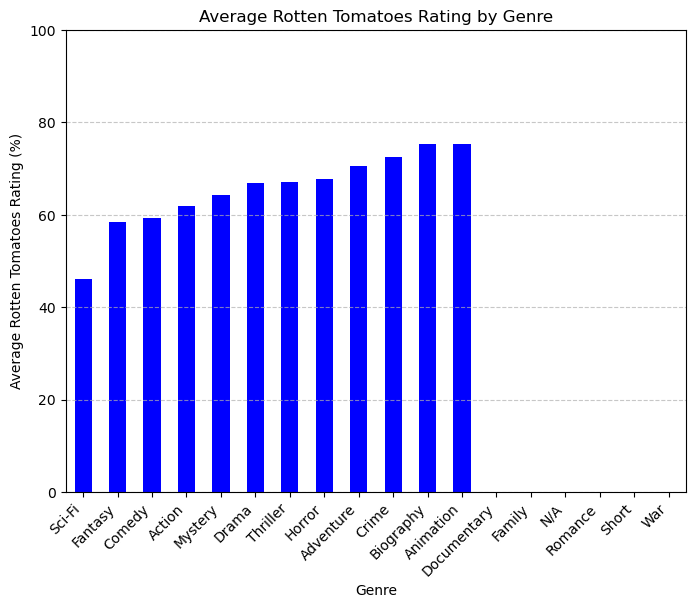

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#graph 1 is a bar graph comparing average rotten tomatoes rating based on genre
filtered_df = clean_movies_df[clean_movies_df['Genre'] != 'N/A'] 

clean_movies_df['Genre'] = clean_movies_df['Genre'].str.split(',').str[0]

avg_ratings_by_genre = clean_movies_df.groupby('Genre')['RottenTomatoesScore (%)'].mean().sort_values()


plt.figure(figsize=(8, 6))
avg_ratings_by_genre.plot(kind='bar', color='blue')

plt.title('Average Rotten Tomatoes Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rotten Tomatoes Rating (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

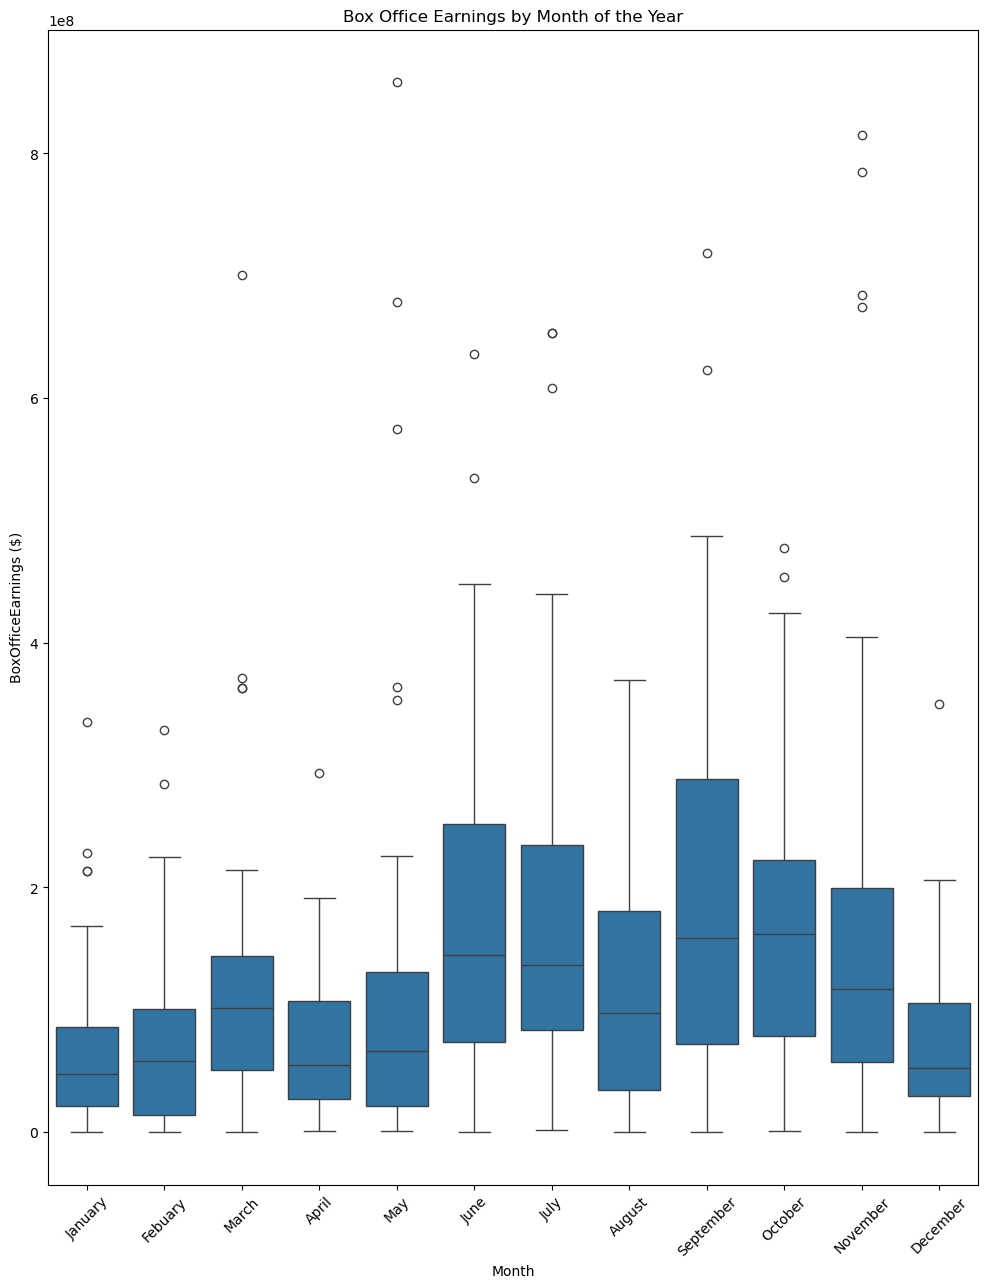

In [8]:
#graph 2 is a box plot comparing box office earnings based on month of the year
clean_movies_df = clean_movies_df[clean_movies_df['ReleaseDate'] != 'N/A']
clean_movies_df['Month'] = clean_movies_df['ReleaseDate'].dt.strftime('%B')
plt.figure(figsize=(12, 15))
plt.title('Box Office Earnings by Month of the Year')
fig1 = sns.boxplot(clean_movies_df, x='Month', y='BoxOfficeEarnings ($)')
plt.xticks(range(12), ['January', 'Febuary', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])
plt.xticks(rotation=45)


plt.show()

Comparing Rotten Tomatoes Rating by Genre gives us insight on how genre might impact a viewer's opinion on the movie. As we can see, it seems like war movies on average do the best. Further analysis is needed, but it seems like some genres are easier for people to like or come out as a better movie.

Box office Earnings by month allows us to see in which times of the year are people most watching movies. This data will be important to answer our second question, which has us predicting the box office earnings, because we can factor in the consideration for popular movie seasons.